In [2]:

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt

import seaborn as sns
from types import MappingProxyType as rodict
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
from scipy.stats import kendalltau, weightedtau

from utils import normalize_columns, encode_categorical, centralize, bootstrap, grouped_weighted_kendall_tau

ModuleNotFoundError: No module named 'arviz'

## Preparing input data 

In [4]:
print('Preparing data...')
INPUT_FILE = '../inputs/transf_scores.csv'
# INPUT_FILE = '../inputs/transf_scores_14_models.csv'
# SAVE_FILE = '../inputs/tmlr_linear_ablations_combinations.csv'
SAVE_FILE = None
# Read the input data
df_full = pd.read_csv(INPUT_FILE)

# Get both scorers and db informations
ALL_SCORERS = df_full['transf_metric'].unique().tolist()
ALL_DBS =  df_full['dataset'].unique().tolist()
SIGNIFICANCE_LEVEL = 0.05
NUM_MODELS = len(df_full['model'].unique())

Preparing data...


### Define variables

In [5]:
DATASET_ORDER = ['caltech101',
                'sun397',
                'voc2007',
                'flowers102',
                'oxfordpets',
                'aircraft',
                'dtd',
                'stanfordcars',
                'brain_tumor_kaggle',
                'breakhis',
                'skin_splits']

SCORER_ORDER = ["ncti_score",        
                "etran_energy_score",
                "pactran_score",     
                "gbc_score",         
                "parc_score",        
                "nleep_score",       
                "leep_score",        
                "logme_score",       
                "tmi_score",         
                "nce_score",         
                "sfda_score",        
                "hscore_score",      
                "reg_hscore_score",  ]


TRANSF_METRICS_TO_NAMES = rodict({
    'imagenet':           'ImageNet',
    'ncti_score':         'NCTI',
    'etran_energy_score': 'ETran',
    'pactran_score':      'PACTran',
    'gbc_score':          'GBC',
    'parc_score':         'PARC',
    'nleep_score':        'NLEEP',
    'leep_score':         'LEEP',
    'logme_score':        'LogME',
    'tmi_score':          'TMI',
    'nce_score':          'NCE',
    'sfda_score':         'SFDA',
    'hscore_score':       'H-Score',
    'reg_hscore_score':   'R.H-Score',
})

DATASET_TO_LEGEND = {
    'sun397'             : 'SUN397',
    'aircraft'           : 'Aircraft',
    'caltech101'         : 'Cal-101',
    'oxfordpets'         : 'Ox.Pets',
    'flowers102'         : 'Ox.Flowers',
    'dtd'                : 'DTD',
    'stanfordcars'       : 'Stan.Cars',
    'voc2007'            : 'VOC 2007',
    'brain_tumor_kaggle' : 'BrainTumor',
    'breakhis'           : 'BreakHis',
    'skin_splits'        : 'ISIC 2019',
}



TRANSF_METRICS_TO_NAMES = rodict({
    'overall': 'Linear Overall',
    'per_scorer': 'Linear per Scorer',
    'per_scorer_dataset': 'Linear per Scorer/Dataset',
    'svm': 'SVM',
    'lsq': 'Least Squares'
})


DECIMALS = 3



In [ ]:
def my_bootstrap(x, y, *, groups=None): 
    def is_constant_array(arr):
        return np.all(arr == arr[0])

    def kendall_taus(x, y):
        if is_constant_array(x):
            if is_constant_array(y):
                # This should be an exceedingly rare situation in which we sampled the same value n times
                pass
            else:
                # If the scores are constant when the metric is not, we assign no correlation/predictive power to the
                # sample we handle this explicitly because kendalltau/weightedtau returns NaN in this case
                return 0, 0
        tau, _ = kendalltau(x, y)
        if np.isnan(tau) or np.isinf(tau):
            print('Warning: Nonfinite tau', tau, 'for', x, y)
        wtau, _ = weightedtau(x, y)
        return tau, wtau

    def grouped_kendall_taus(x, y, g):
        if is_constant_array(x):
            if is_constant_array(y):
                pass
            else:
                return 0, 0
        tau = grouped_weighted_kendall_tau(x, y, g, weighter=lambda r: 1)
        if np.isnan(tau) or np.isinf(tau):
            print('Warning: Nonfinite tau', tau, 'for', x, y)
        wtau = grouped_weighted_kendall_tau(x, y, g)
        return tau, wtau

    if groups is None:
        tau, wtau = kendall_taus(x, y)
        kendall = bootstrap((x, y), kendall_taus, n_bootstraps=1000)
    else:
        tau, wtau = grouped_kendall_taus(x, y, groups)
        kendall = bootstrap((x, y, groups), grouped_kendall_taus, n_bootstraps=1000)

    return dict(
            tau=tau,
            wtau=wtau,
            bootstrapped_tau=[k[0] for k in kendall],
            bootstrapped_wtau=[k[1] for k in kendall],
        )

#### SVM Regression 

In [ ]:
def sklearn_regression(df_train, df_test, regression_fn):
    # prepare data for input 
    train_data = dict()
    train_data['z_transf_score'] = list()
    train_data['z_test_score'] = list()
    for idx, scorer in enumerate(SCORERS_TO_KEEP):
        df_scorer = df_train[df_train['transf_metric'] == scorer]
        train_data['z_transf_score'].append(df_scorer['z_transf_score'].to_list())
        
        # Enter here only once to avoid repeated samples
        if idx == 0:
            train_data['z_test_score'].extend(df_scorer['z_test_score'].to_list())

    # concatenate scorers information as features (columns)
    train_data['z_transf_score'] = np.column_stack(train_data['z_transf_score']) # Shape: (N_Archs*N_TrainDatasets, N_Trainscorers) 
    # print(train_data['z_transf_score'].shape) 
    train_data['z_test_score'] = np.array(train_data['z_test_score']) # Shape: (N_Archs*N_TrainDatasets, 1)
    # print(train_data['z_test_score'].shape)
    # print(f"{train_data['z_transf_score'].shape=} / {train_data['z_test_score'].shape=}")

    test_data = dict()
    test_data['z_transf_score'] = list()
    test_data['z_test_score'] = list()
    for idx, scorer in enumerate(SCORERS_TO_KEEP):
        df_scorer = df_test[df_test['transf_metric'] == scorer]
        test_data['z_transf_score'].append(df_scorer['z_transf_score'].to_list())
        # Enter here only once to avoid repeated samples
        if idx == 0:
            test_data['z_test_score'].extend(df_scorer['z_test_score'].to_list())

    # concatenate scorers information as features (columns)
    test_data['z_transf_score'] = np.column_stack(test_data['z_transf_score']) # Shape: (N_Archs*N_TestDatasets, N_Trainscorers)  
    test_data['z_test_score'] = np.array(test_data['z_test_score']) # Shape: (N_Archs*N_TestDatasets, 1)
    # print(f"{test_data['z_transf_score'].shape=} / {test_data['z_test_score'].shape=}")

    # train and test SVM for regression 
    regression_fn.fit(X=train_data['z_transf_score'], 
                      y=train_data['z_test_score'])
    predictions = regression_fn.predict(test_data['z_transf_score']) # Shape (N_Archs, 1) 

    # print(regression_fn.coef_.shape, regression_fn.coef_)
    # print(f"{predictions.shape=}")
    # kendall_regression = my_bootstrap(predictions, test_data['z_test_score'])
    return predictions, regression_fn.coef_


### Same scheme as in + 3 top 

In [ ]:
# Iterate over all available DBS to vary the test DB (leave-one-dataset-out evaluation scheme)

list_summary = []





# Scheme + 3 top + I  
# SCORERS_TO_KEEP = [
#                 'pactran_score',
#                 'etran_energy_score',
#                 'ncti_score',
# ]
SCORERS_TO_KEEP = SCORER_ORDER

for dataset_idx, TEST_DB in enumerate(ALL_DBS, start=1):
    TRAIN_DBS = [db for db in ALL_DBS if db != TEST_DB]

    SELECTED_SCORERS = SCORERS_TO_KEEP.copy()

    DATASETS = sorted(set(TRAIN_DBS) - {TEST_DB}) + [TEST_DB]
    df = df_full[df_full['transf_metric'].isin(SELECTED_SCORERS) & df_full['dataset'].isin(DATASETS)].copy()
    group_by = ['transf_metric', 'dataset']
    columns_to_normalize = ['test_score', 'transf_score']
    normalize_columns(df, columns=columns_to_normalize, group_by=group_by) # in-place normalization 
    
    # Encode the categorical variables as integers
    translation = encode_categorical(df, 
                                    columns=['model', 'transf_metric', 'dataset'], 
                                    encoding = dict( model=None, transf_metric=None, dataset=dict(enumerate(DATASETS, start=1)) ))
    
    # Selects and validates the data
    df_train = df[df['dataset'].isin(TRAIN_DBS)]
    df_test = df[df['dataset'] == TEST_DB]
    if len(df_train) == 0:
        raise ValueError('No training data meets the criteria!')
    if len(df_test) == 0:
        raise ValueError('No test data meets the criteria!')

    df_target_check = df_test.groupby('model')['test_score'].transform(centralize).abs().max()
    if df_target_check > 1e-6:
        raise ValueError('The test scores are not constant for each model on the test dataset!')

    if df_test['classes'].nunique() != 1:
        raise ValueError('The test dataset has different class counts on different entries!')


    # print(f'[{TEST_DB=}][{include_imagenet=}] Fitting models...')

    preds_squares, preds_coefs = sklearn_regression(df_train, df_test, regression_fn=LinearRegression())

    # y = df_test.head(NUM_MODELS)['z_test_score'].to_list()
# 
    method_list = [(f'lsq_scorer', 
                    preds_coefs)]
    
    for (method_name, method_coefs) in method_list:
        for (scorer_id, scorer_name) in enumerate(SCORERS_TO_KEEP):
            list_summary.append([method_name, 
                                 TEST_DB,
                                 scorer_name, 
                                 method_coefs[scorer_id]]) 
    # break 

In [ ]:
list_summary

[['lsq_scorer', 'sun397', 'ncti_score', 0.24593336078873304],
 ['lsq_scorer', 'sun397', 'etran_energy_score', 0.372135521618249],
 ['lsq_scorer', 'sun397', 'pactran_score', 0.34623425384247886],
 ['lsq_scorer', 'sun397', 'gbc_score', 0.04026445485197124],
 ['lsq_scorer', 'sun397', 'parc_score', -0.05602171347721459],
 ['lsq_scorer', 'sun397', 'nleep_score', -0.029082851882942247],
 ['lsq_scorer', 'sun397', 'leep_score', 0.15181752393561485],
 ['lsq_scorer', 'sun397', 'logme_score', 0.12602251882451548],
 ['lsq_scorer', 'sun397', 'tmi_score', -0.08035828042426954],
 ['lsq_scorer', 'sun397', 'nce_score', 0.07380559223157114],
 ['lsq_scorer', 'sun397', 'sfda_score', -0.09588788830416378],
 ['lsq_scorer', 'sun397', 'hscore_score', 0.09899238696037878],
 ['lsq_scorer', 'sun397', 'reg_hscore_score', -0.1707286864683834],
 ['lsq_scorer', 'aircraft', 'ncti_score', 0.36551196002921565],
 ['lsq_scorer', 'aircraft', 'etran_energy_score', 0.4288295575516083],
 ['lsq_scorer', 'aircraft', 'pactran_s

In [ ]:
summary_df = pd.DataFrame(list_summary, columns=['method', 
                                                 'test_db', 
                                                 'scorer_name', 
                                                 'weight'])

In [ ]:
summary_df['test_db'] = summary_df['test_db'].replace(DATASET_TO_LEGEND)
summary_df['scorer_name'] = summary_df['scorer_name'].replace(TRANSF_METRICS_TO_NAMES)

In [ ]:
summary_df

,method,test_db,scorer_name,weight
0,lsq_scorer,SUN397,ncti_score,0.245933
1,lsq_scorer,SUN397,etran_energy_score,0.372136
2,lsq_scorer,SUN397,pactran_score,0.346234
3,lsq_scorer,SUN397,gbc_score,0.040264
4,lsq_scorer,SUN397,parc_score,-0.056022
...,...,...,...,...
138,lsq_scorer,ISIC 2019,tmi_score,-0.122833
139,lsq_scorer,ISIC 2019,nce_score,0.069155
140,lsq_scorer,ISIC 2019,sfda_score,-0.006458
141,lsq_scorer,ISIC 2019,hscore_score,0.129019


In [ ]:
summary_df

,method,test_db,scorer_name,weight
0,lsq_scorer,SUN397,ncti_score,0.245933
1,lsq_scorer,SUN397,etran_energy_score,0.372136
2,lsq_scorer,SUN397,pactran_score,0.346234
3,lsq_scorer,SUN397,gbc_score,0.040264
4,lsq_scorer,SUN397,parc_score,-0.056022
...,...,...,...,...
138,lsq_scorer,ISIC 2019,tmi_score,-0.122833
139,lsq_scorer,ISIC 2019,nce_score,0.069155
140,lsq_scorer,ISIC 2019,sfda_score,-0.006458
141,lsq_scorer,ISIC 2019,hscore_score,0.129019


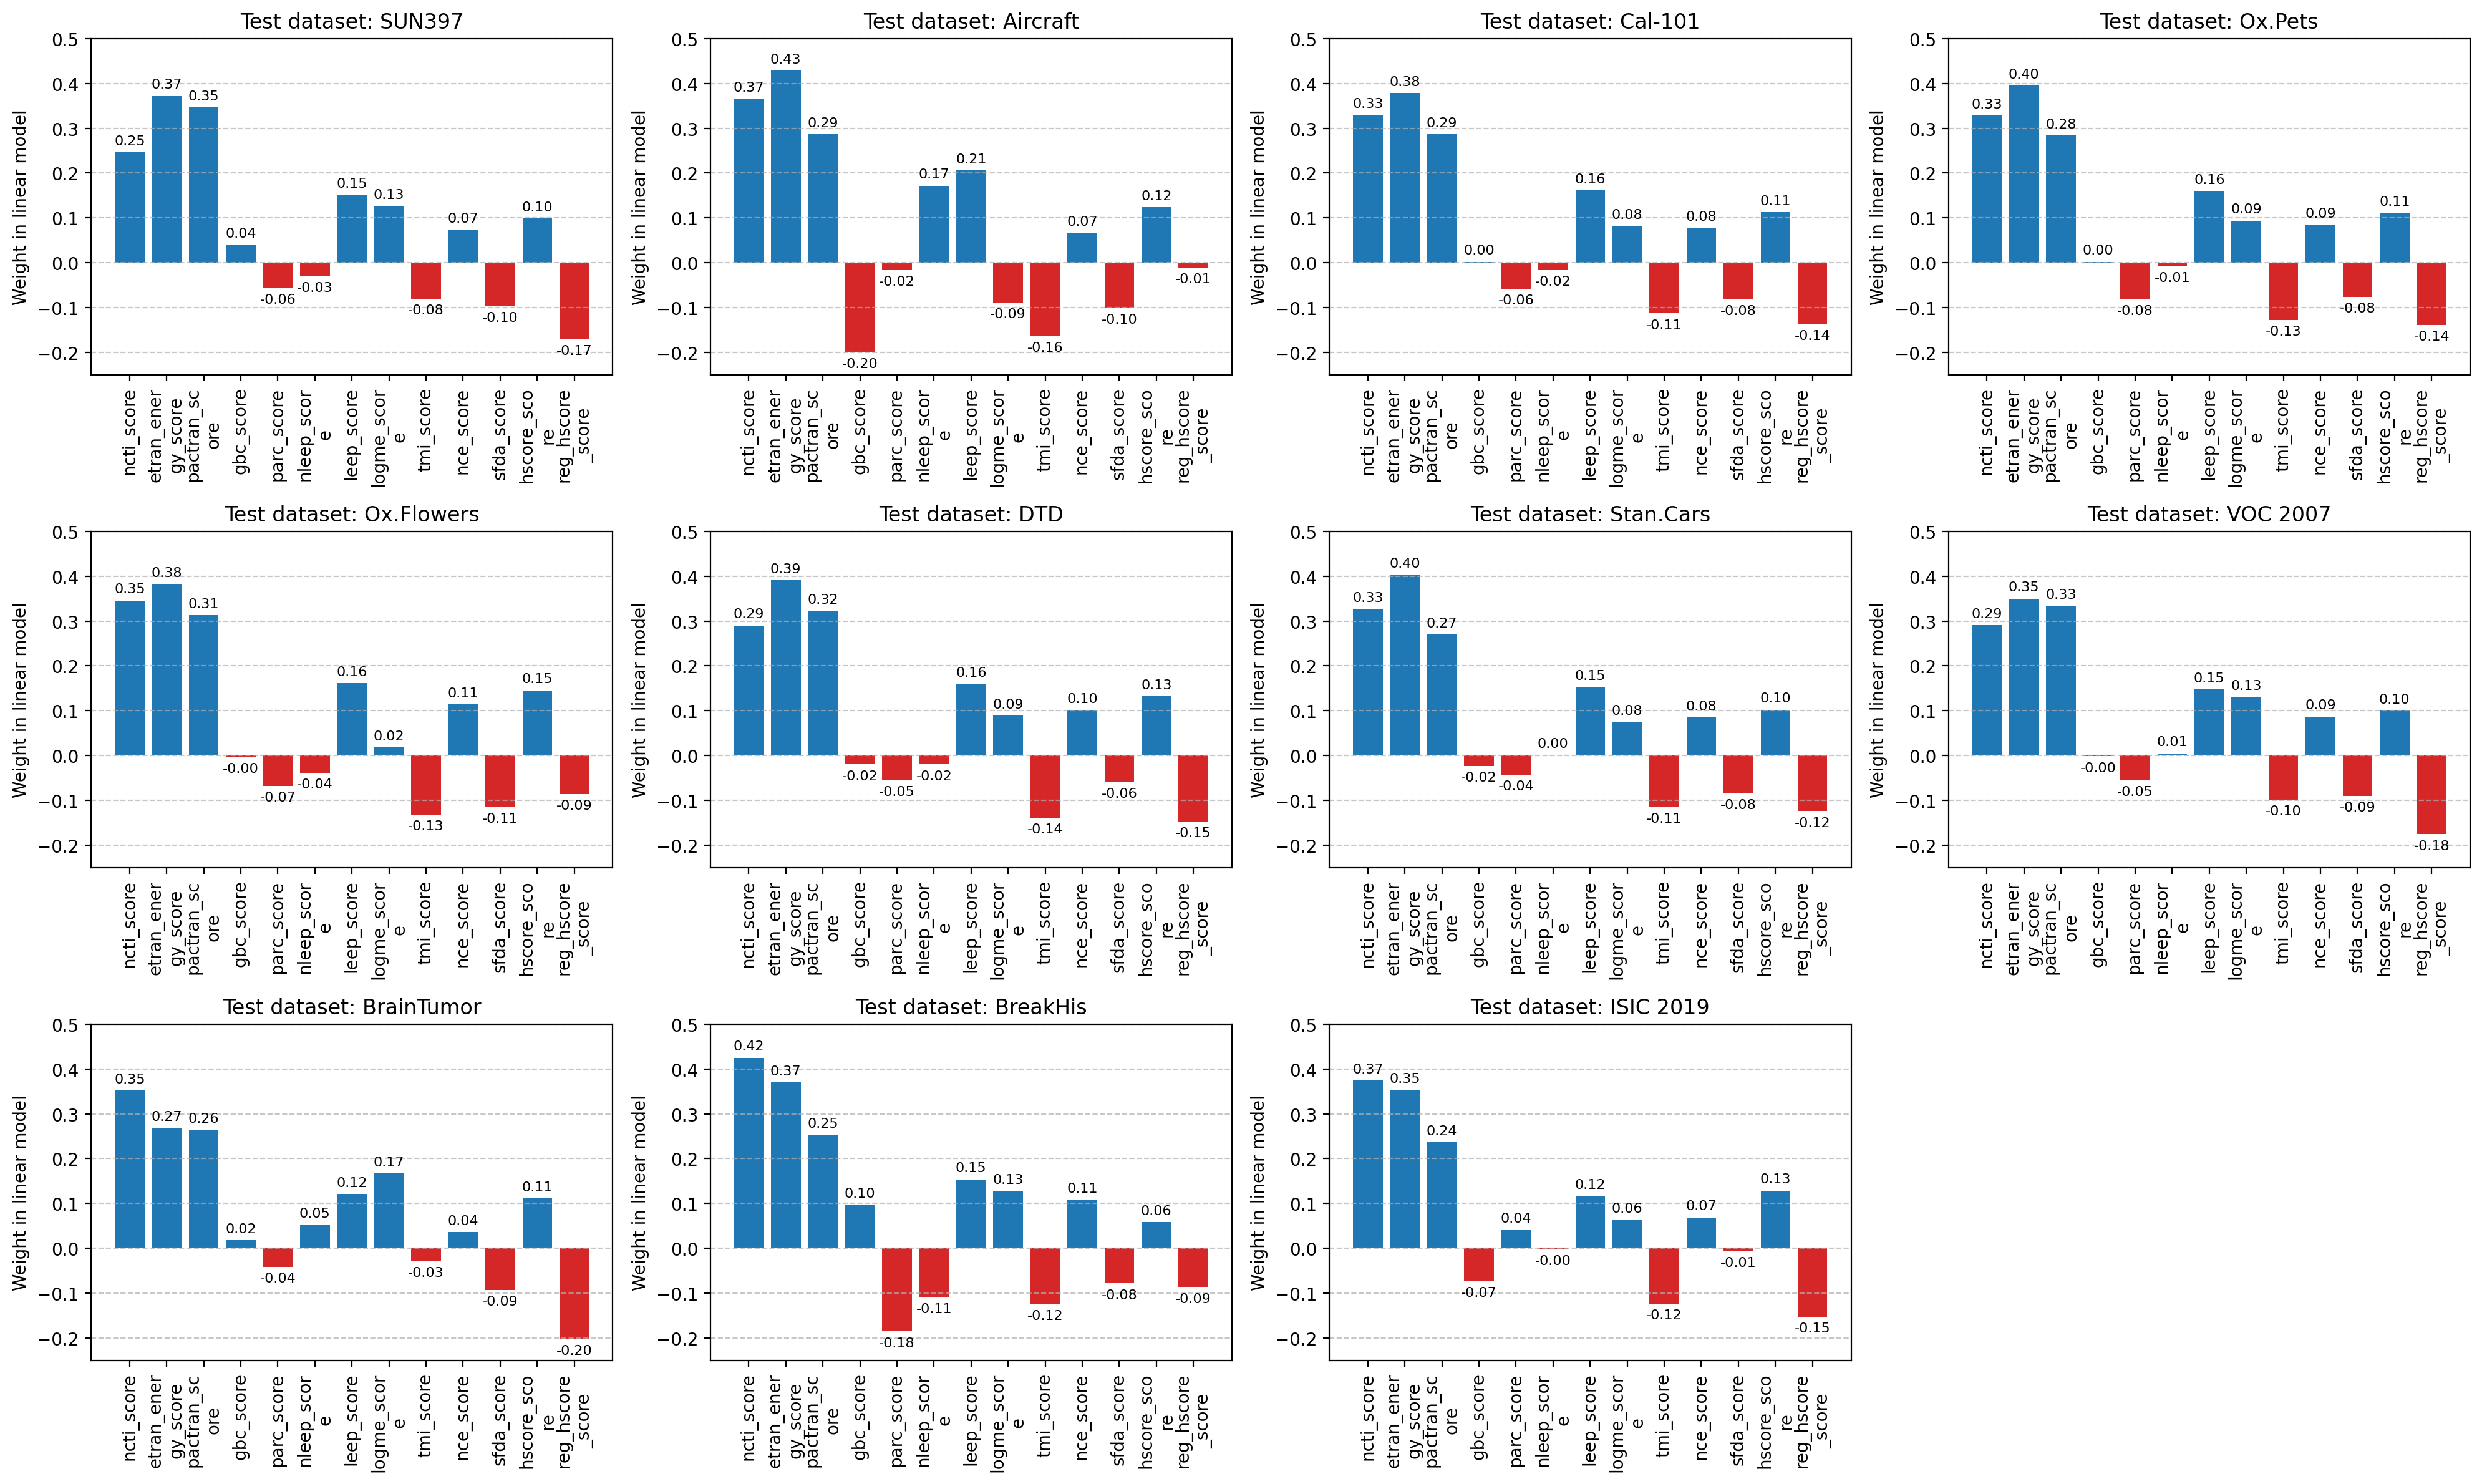

In [ ]:
import matplotlib.pyplot as plt
import textwrap
import math

# Make a copy so we don't overwrite the original DataFrame
df_plot = summary_df.copy()

# Set color palette: blue for positive, red for negative
df_plot['color'] = df_plot['weight'].apply(lambda x: 'tab:blue' if x >= 0 else 'tab:red')

# Unique datasets
test_dbs = df_plot['test_db'].unique()

# Grid layout: wrap to 4 columns
n_cols = 4
n_rows = math.ceil(len(test_dbs) / n_cols)

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=False,
    dpi=200,
)

# Flatten axes for easier iteration
axes = axes.flatten()

for ax_idx, test_db in enumerate(test_dbs):
    ax = axes[ax_idx]
    data = df_plot[df_plot['test_db'] == test_db]

    # Bar plot
    bars = ax.bar(
        x=range(len(data)),
        height=data['weight'],
        color=data['color']
    )

    # Annotate bars
    for bar, height in zip(bars, data['weight']):
        if height >= 0:
            ax.annotate(
                f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2., height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=8, color='black'
            )
        else:
            ax.annotate(
                f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2., height),
                xytext=(0, -3),
                textcoords='offset points',
                ha='center', va='top', fontsize=8, color='black'
            )

    # Set x-axis labels with wrapping
    wrapped_labels = [
        "\n".join(textwrap.wrap(label, width=10))
        for label in data['scorer_name']
    ]
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(wrapped_labels, rotation=90)

    ax.set_ylabel("Weight in linear model")
    ax.set_ylim(-0.25, 0.5)

    ax.set_title(f'Test dataset: {test_db}', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide unused subplots
for ax in axes[len(test_dbs):]:
    ax.axis('off')


plt.tight_layout()
plt.show()


## Plot average grouped tau across all scorer's combinations for training ensemble  

In [6]:
# CSV_PATH = '/experimentos/codes/doutorado/btb/gradstat/inputs/tmlr_linear_ablations_combinations.csv'
CSV_PATH = '/home/levy/experimentos/codes/doutorado/btb/gradstat/inputs/tmlr_linear_ablations_combinations.csv'

df_grouped_stats = pd.read_csv(CSV_PATH)
df_grouped_stats['num_methods'] = df_grouped_stats['method_name'].apply(lambda x: str(x.split('_')[-2]).zfill(2))
df_grouped_stats['method_name'] = df_grouped_stats['method_name'].apply(lambda x: "_".join(x.split('_')[:-2]))
df_grouped_stats['method_name'] = df_grouped_stats['method_name'].replace(TRANSF_METRICS_TO_NAMES)

In [7]:
df_grouped_stats

,method_name,combination,wtau,num_methods
0,Linear Overall,ncti_score,0.663442,01
1,Linear per Scorer,ncti_score,0.663442,01
2,Linear per Scorer/Dataset,ncti_score,0.663442,01
3,SVM,ncti_score,0.534879,01
4,Least Squares,ncti_score,0.663442,01
...,...,...,...,...
40945,Linear Overall,"etran_energy_score,pactran_score,gbc_score,par...",0.091402,12
40946,Linear per Scorer,"etran_energy_score,pactran_score,gbc_score,par...",0.653298,12
40947,Linear per Scorer/Dataset,"etran_energy_score,pactran_score,gbc_score,par...",0.653298,12
40948,SVM,"etran_energy_score,pactran_score,gbc_score,par...",0.570026,12


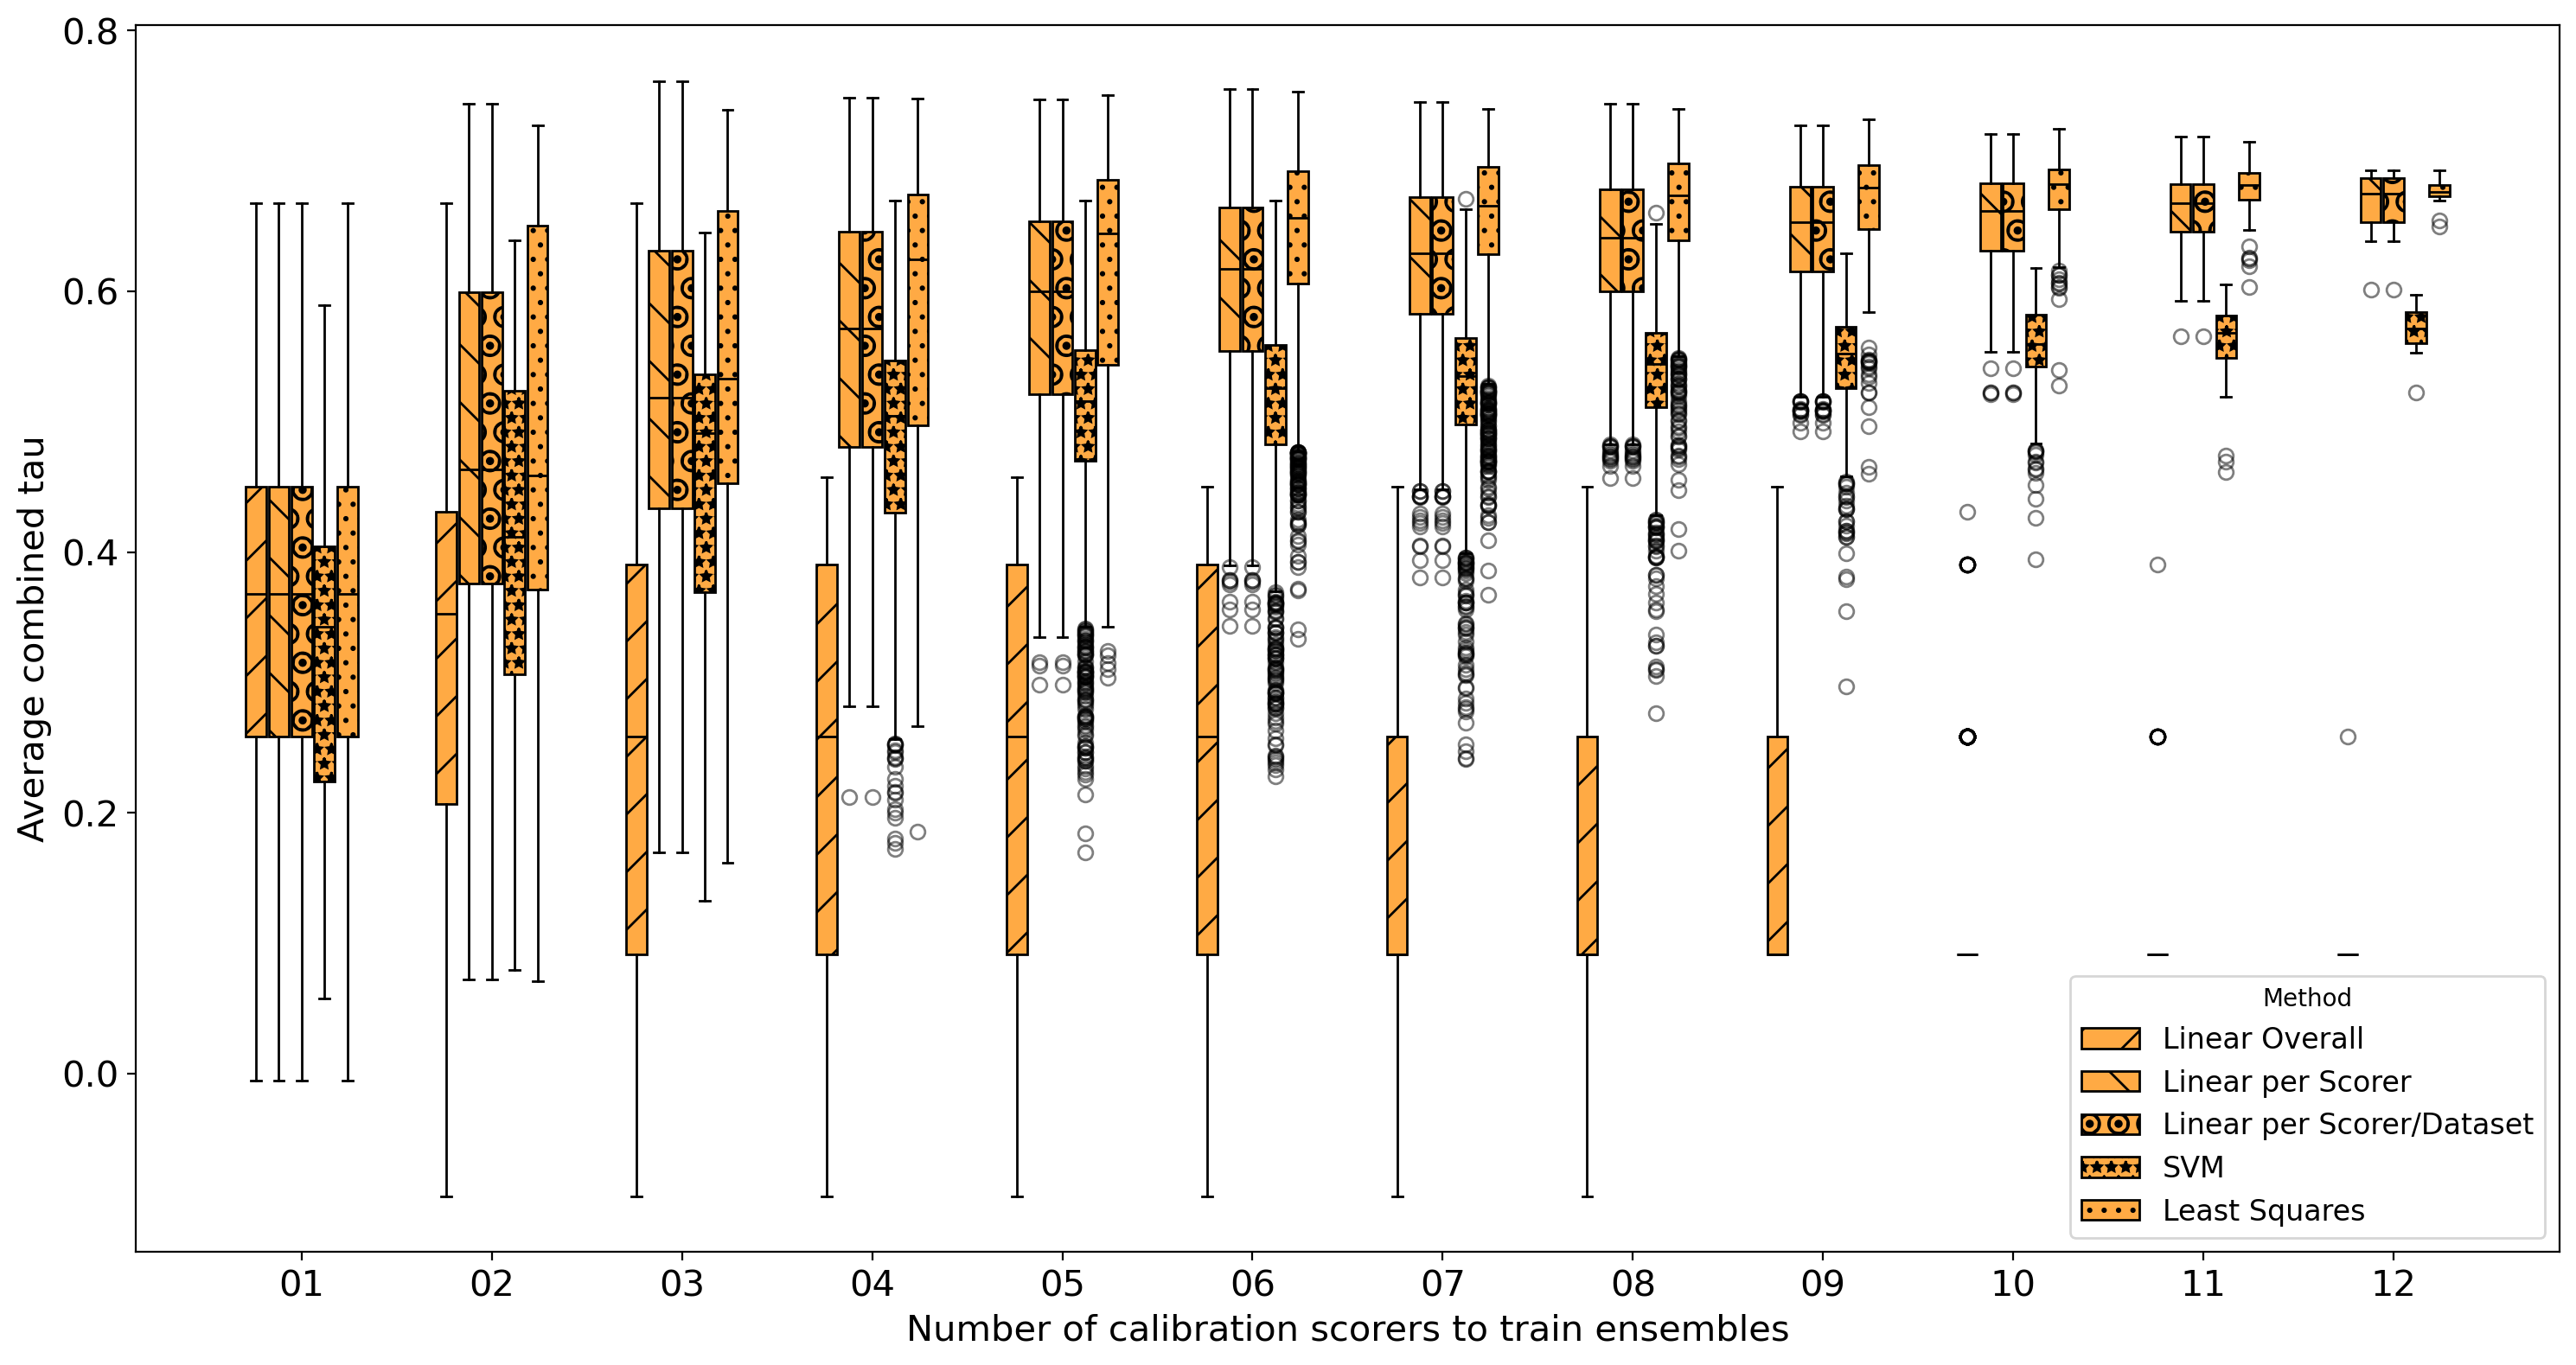

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# --- Configuration ---
method_order = [
    'Linear Overall',
    'Linear per Scorer',
    'Linear per Scorer/Dataset',
    'SVM',
    'Least Squares'
]

colors = [
    "#E69F00",  # Linear Overall
    "#56B4E9",  # Linear per Scorer
    "#009E73",  # Linear per Scorer/Dataset
    "#D55E00",  # SVM
    "#CC79A7"   # Least Squares
]

SINGLE_COLOR = "#FF8C00BB"

# choose hatch patterns (reused if more methods than patterns)
hatch_patterns = ['/', '\\', 'O.', '**', '..']

# sorted x groups
num_methods_values = sorted(df_grouped_stats['num_methods'].unique())

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 8), 
                       dpi=200)

# total allowed width for all boxes in a single group (tweak if needed)
total_group_width = 0.6
box_width = total_group_width / len(method_order)

for group_idx, num_methods in enumerate(num_methods_values):
    for method_idx, method in enumerate(method_order):
        vals = df_grouped_stats.loc[
            (df_grouped_stats['num_methods'] == num_methods) &
            (df_grouped_stats['method_name'] == method),
            'wtau'
        ].dropna().values

        # skip if there's no data for this (num_methods, method) pair
        if vals.size == 0:
            continue

        # center the group at integer `group_idx`; offset boxes within group
        offset = (method_idx - (len(method_order) - 1) / 2) * box_width
        position = group_idx + offset

        bp = ax.boxplot(
            vals,
            positions=[position],
            widths=box_width * 0.9,
            patch_artist=True,
            manage_ticks=False
        )

        # style the box elements
        # face_color = colors[method_idx]
        face_color = SINGLE_COLOR
        hatch = hatch_patterns[method_idx % len(hatch_patterns)]
        for patch in bp['boxes']:
            patch.set_facecolor(face_color)
            patch.set_hatch(hatch)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)
        for whisker in bp['whiskers']:
            whisker.set_color('black')
        for cap in bp['caps']:
            cap.set_color('black')
        for median in bp['medians']:
            median.set_color('black')
        for flier in bp['fliers']:
            flier.set(marker='o', color='black', alpha=0.5)

# set x ticks at group centers
ax.set_xticks(range(len(num_methods_values)))
ax.set_xticklabels(num_methods_values)


ax.set_xlabel("Number of calibration scorers to train ensembles",
              size=15)
ax.set_ylabel("Average combined tau", 
              size=15)

# Legend using Patch objects (supports hatch)
legend_handles = [
    mpatches.Patch(
        # facecolor=colors[i],
        facecolor=SINGLE_COLOR,
        edgecolor='black',
        hatch=hatch_patterns[i % len(hatch_patterns)],
        label=method_order[i]
    )
    for i in range(len(method_order))
]

ax.legend(
    handles=legend_handles,
    title="Method",
    fontsize=12
)

plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.tight_layout()
plt.savefig('../outputs/boxplot_combinations_ensemble.pdf', 
            bbox_inches='tight',
            pad_inches=0)
plt.show()
